# **Importing Required Libraries**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Loading the Data**

In [17]:


df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/4877028-Retail_Sales_Data.xlsx')
df.head()

,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag
0,13-04-2023,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,29973.06,39,1168949.34,5,1.110502e+06,Returning,Debit Card,Yes,422,4.4,South,0
1,25-10-2024,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,46933.78,2,93867.56,15,7.978743e+04,Returning,UPI,No,302,4.1,North,0
2,28-02-2023,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,39280.28,44,1728332.32,15,1.469082e+06,Returning,Cash,No,184,3.8,East,0
3,16-06-2023,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,40439.03,9,363951.27,5,3.457537e+05,New,UPI,Yes,493,3.7,South,0
4,23-05-2024,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,9193.58,4,36774.32,5,3.493560e+04,Returning,Credit Card,No,359,3.5,West,0


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
df.shape

(73000, 19)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 73000 non-null  object 
 1   Store_ID             73000 non-null  object 
 2   Store_Location       73000 non-null  object 
 3   Product_ID           73000 non-null  object 
 4   Product_Category     73000 non-null  object 
 5   Product_Subcategory  73000 non-null  object 
 6   Brand                73000 non-null  object 
 7   Unit_Price           73000 non-null  float64
 8   Units_Sold           73000 non-null  int64  
 9   Total_Sales          73000 non-null  float64
 10  Discount_Percentage  73000 non-null  int64  
 11  Revenue              73000 non-null  float64
 12  Customer_Type        73000 non-null  object 
 13  Payment_Mode         73000 non-null  object 
 14  Promotion_Applied    73000 non-null  object 
 15  Stock_On_Hand        73000 non-null 

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit_Price,73000.0,25110.208554,14393.607981,100.110,12728.855000,25071.8000,37557.3375,49999.85
Units_Sold,73000.0,24.894589,14.134824,1.000,13.000000,25.0000,37.0000,49.00
Total_Sales,73000.0,626138.239282,544854.836919,144.700,175985.232500,471357.7200,953986.3800,2447350.08
Discount_Percentage,73000.0,10.010411,7.064131,0.000,5.000000,10.0000,15.0000,20.00
Revenue,73000.0,563476.477603,493890.517322,122.995,157537.656875,422356.4515,857115.5850,2447350.08
Stock_On_Hand,73000.0,274.624712,129.663977,50.000,162.000000,274.0000,387.0000,499.00
Store_Rating,73000.0,4.249421,0.434722,3.500,3.900000,4.2000,4.6000,5.00
Holiday_Flag,73000.0,0.012288,0.110167,0.000,0.000000,0.0000,0.0000,1.00


# **Data Cleaning**

In [33]:
# Checking Null Values
df.isnull().sum()

,0
Date,0
Store_ID,0
Store_Location,0
Product_ID,0
Product_Category,0
Product_Subcategory,0
Brand,0
Unit_Price,0
Units_Sold,0
Total_Sales,0


In [34]:
# Checking Duplicated Values
df.duplicated().sum()

np.int64(0)

In [35]:
# Fixing Data Types
df["Date"] = pd.to_datetime(df["Date"])
df["Total_Sales"] = pd.to_numeric(df["Total_Sales"])

- Dataset does not contains missing values and duplicated values.
- The Data is **Clean and Structured**.

# **Feature Engineering**

In [36]:
# Adding Usefull Columns for Analysis
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.day_name()

# **Exploratory Data Anlysis**

In [46]:
# Total sales by year
df.groupby("Year")["Total_Sales"].sum()

,Total_Sales
Year,
2023,"22,926,576,747.29"
2024,"22,781,514,720.28"


In [47]:
# Total sales by month
df.groupby("Month")["Total_Sales"].sum()

,Total_Sales
Month,
1,"3,985,421,024.68"
2,"3,497,406,357.66"
3,"3,787,818,177.89"
4,"3,725,032,614.33"
5,"3,803,854,605.56"
6,"3,699,748,595.83"
7,"3,894,191,386.10"
8,"3,936,941,824.93"
9,"3,781,083,937.98"


In [48]:
# Average sales by quarter
df.groupby("Quarter")["Total_Sales"].mean()

,Total_Sales
Quarter,
1,"623,652.37"
2,"619,921.37"
3,"628,332.73"
4,"632,518.43"


In [49]:
# Top 10 Stores Over Total Sales
store_sales = df.groupby("Store_ID")["Total_Sales"].sum().sort_values(ascending=False)
store_sales.head(10)

,Total_Sales
Store_ID,
STR_103,"5,803,046,637.11"
STR_102,"5,758,117,039.56"
STR_101,"5,751,483,597.78"
STR_104,"5,749,821,347.88"
STR_105,"5,737,160,207.60"
STR_107,"5,672,850,014.33"
STR_108,"5,634,169,569.91"
STR_106,"5,601,443,053.40"


In [50]:
# top 10 categories
category_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)
print(category_sales.head(10))

Product_Category
Electronics       9,239,969,401.04
Home Appliances   9,179,564,431.74
Fashion           9,126,090,849.98
Groceries         9,095,668,953.37
Sports            9,066,797,831.44
Name: Total_Sales, dtype: float64


In [51]:
# Day of Week Patterens
dow_sales = df.groupby("DayOfWeek")["Total_Sales"].mean()
print(dow_sales)

DayOfWeek
Friday      624,830.86
Monday      623,500.61
Saturday    623,420.45
Sunday      620,396.68
Thursday    633,595.33
Tuesday     632,794.44
Wednesday   624,498.63
Name: Total_Sales, dtype: float64


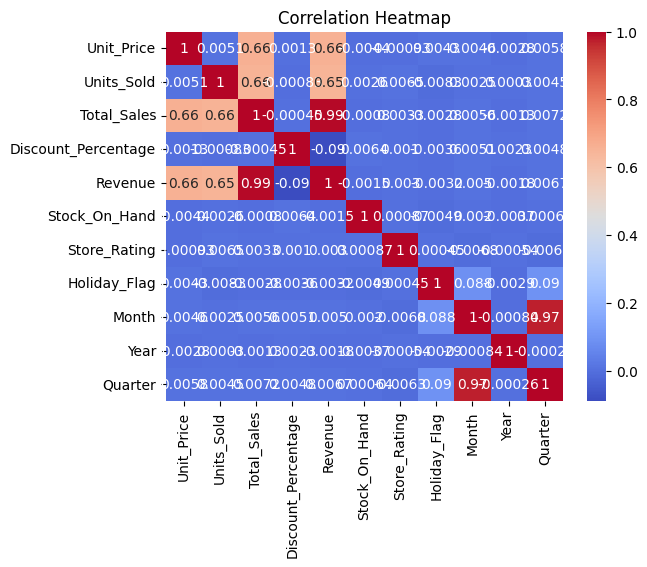

In [52]:
numerical_cols = df.select_dtypes(include=['number']).columns

sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# **Data Visualization**

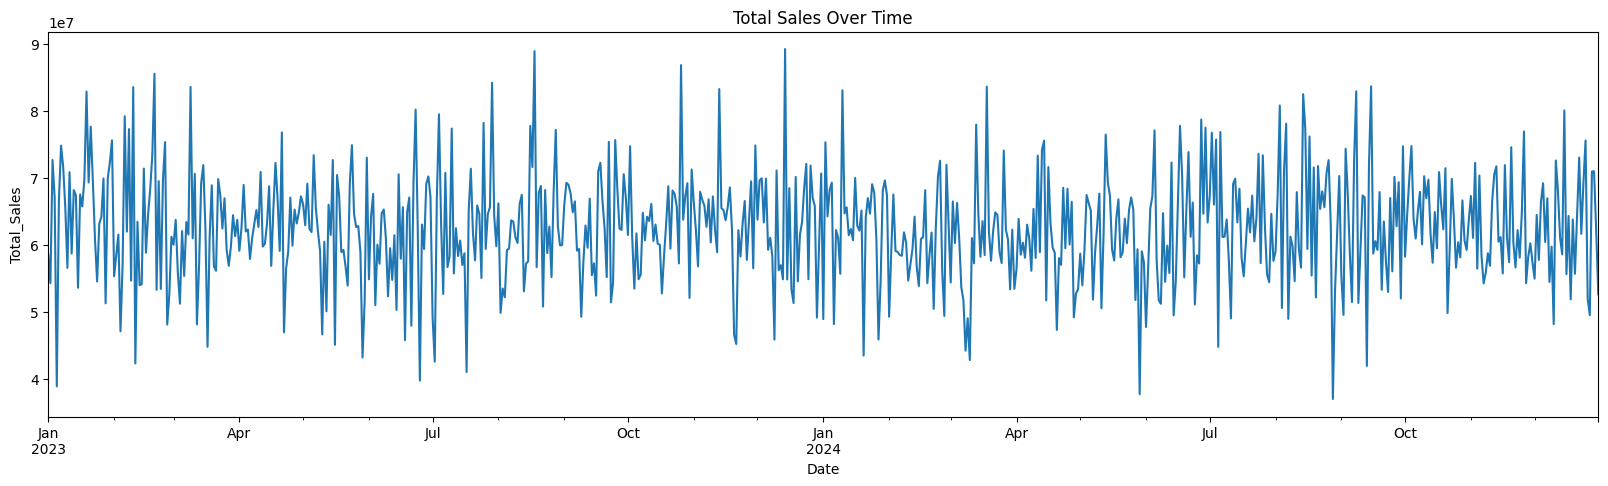

In [53]:
# Sales Trend over Time
df.groupby("Date")["Total_Sales"].sum().plot(figsize=(20,5))
plt.title("Total Sales Over Time")
plt.ylabel("Total_Sales")
plt.xlabel("Date")
plt.show()

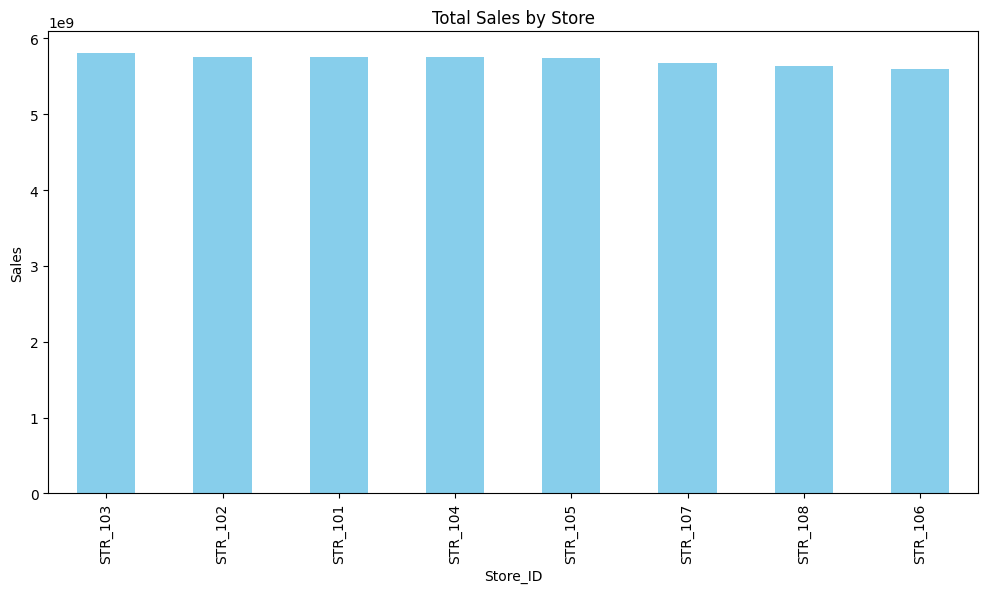

In [54]:
# total revenue across stores.
store_sales = df.groupby("Store_ID")["Total_Sales"].sum().sort_values(ascending=False)
store_sales.plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title("Total Sales by Store")
plt.ylabel("Sales")
plt.show()

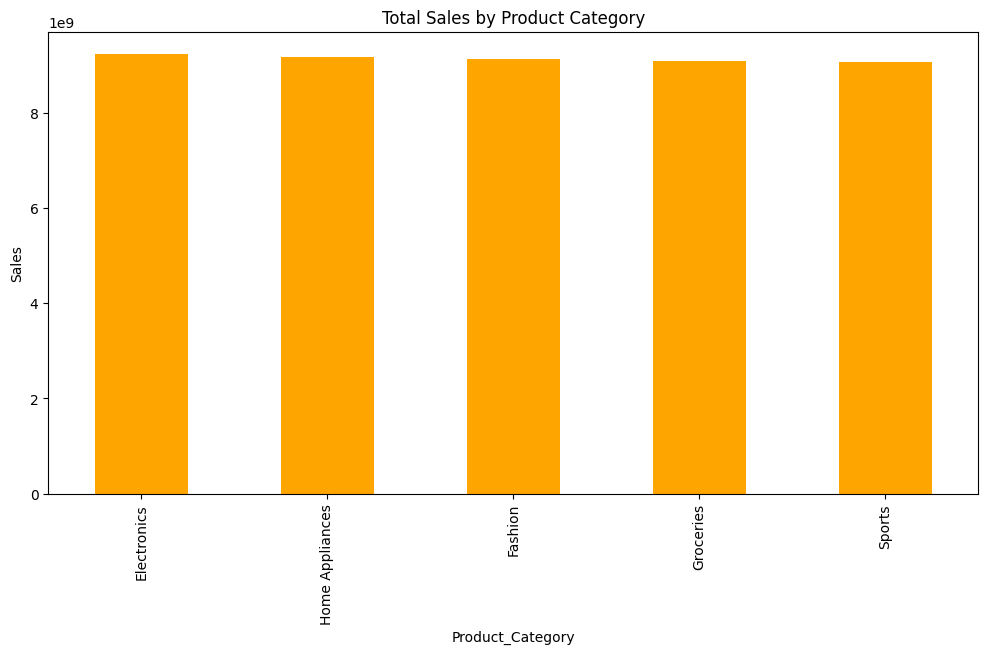

In [55]:
# Total Sales by Product Category
category_sales.plot(kind="bar", figsize=(12,6), color="orange")
plt.title("Total Sales by Product Category")
plt.ylabel("Sales")
plt.show()

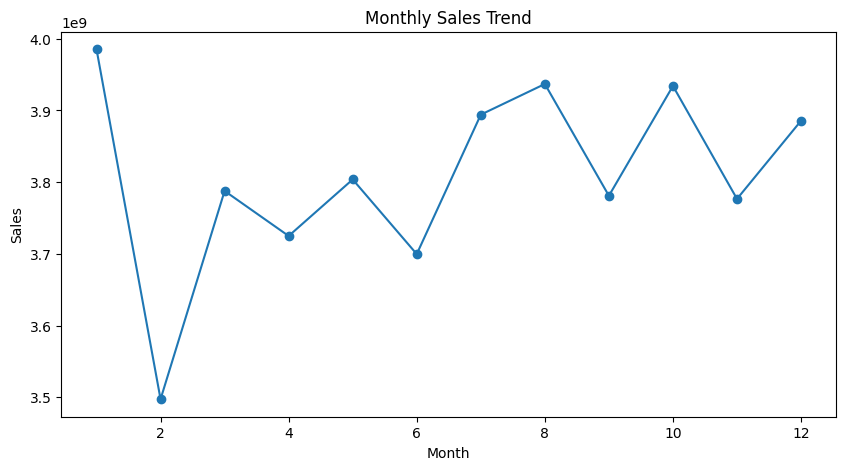

In [56]:
# Monthly Sales Trend
monthly_sales = df.groupby("Month")["Total_Sales"].sum()
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.show()

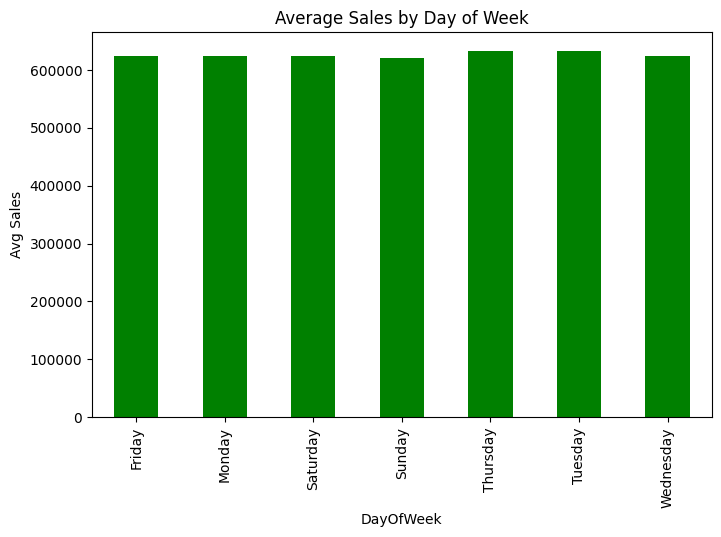

In [57]:
# Average Sales by Day of Week
dow_sales.plot(kind="bar", figsize=(8,5), color="green")
plt.title("Average Sales by Day of Week")
plt.ylabel("Avg Sales")
plt.show()

# **Sales Forecasting**

In [58]:
sales = df.groupby("Date")["Total_Sales"].sum().reset_index()

In [59]:
from prophet import Prophet

sales = sales.rename(columns={"Date":"ds","Total_Sales":"y"})

model = Prophet()
model.fit(sales)

# Forecasting next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper
816,2025-03-27,"62,016,762.75","50,911,855.57","72,228,156.26"
817,2025-03-28,"61,233,619.58","51,590,488.31","71,476,290.46"
818,2025-03-29,"61,812,333.33","51,682,460.75","71,884,544.58"
819,2025-03-30,"61,523,435.55","51,221,654.63","71,109,679.91"
820,2025-03-31,"61,578,760.19","51,859,215.42","71,983,327.99"


In [60]:
# Example if your columns are Date and Total_Sales

sales = df.groupby('Date')['Total_Sales'].sum().reset_index()

sales.columns = ['ds', 'y']

sales.head()

,ds,y
0,2023-01-01,"58,573,510.66"
1,2023-01-02,"54,332,756.95"
2,2023-01-03,"72,712,543.16"
3,2023-01-04,"67,110,537.19"
4,2023-01-05,"38,916,642.05"


In [61]:
sales['ds'] = pd.to_datetime(sales['ds'])
sales['y'] = pd.to_numeric(sales['y'], errors='coerce')

sales_series = sales.set_index('ds')['y']

In [31]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_series, order=(1,1,1))
fit = model.fit()

print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  731
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12674.524
Date:                Sun, 14 Jun 2026   AIC                          25355.048
Time:                        06:02:55   BIC                          25368.827
Sample:                             0   HQIC                         25360.364
                                - 731                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0319      0.042     -0.765      0.444      -0.114       0.050
ma.L1         -0.9918      0.007   -144.591      0.000      -1.005      -0.978
sigma2      8.368e+13   3.59e-19   2.33e+32      0.0

## **Evaluation**

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = sales_series[-30:]   # last 30 days actual
y_pred = forecast["yhat"][-30:]   # last 30 days predicted

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae, "RMSE:", rmse)

MAE: 6775853.87440982 RMSE: 8266830.589058183


# **Store Segmentation**

In [63]:
store_features = df.groupby("Store_ID").agg({
    "Total_Sales": ["mean", "std", "sum"],
    "Product_Category": "nunique"
}).reset_index()

store_features.columns = ["Store", "Avg_Sales", "Sales_Volatility", "Total_Sales", "Category_Count"]

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(store_features[["Avg_Sales","Sales_Volatility","Total_Sales","Category_Count"]])

In [65]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
store_features["Cluster"] = kmeans.fit_predict(X_scaled)

In [66]:
store_features.groupby("Cluster")[["Avg_Sales","Sales_Volatility","Total_Sales","Category_Count"]].mean()

,Avg_Sales,Sales_Volatility,Total_Sales,Category_Count
Cluster,,,,
0,"628,737.24","545,531.55","5,770,328,341.52",5.00
1,"621,667.23","543,144.76","5,661,405,711.31",5.00
2,"636,296.45","549,709.28","5,751,483,597.78",5.00


In [67]:
# Segmentation Results saved in csv file
store_features.to_csv("store_segmentation_results.csv", index=False)

# Business Insights & Recommendations

## Key Findings

- Electronics category generated the highest revenue.
- Store S102 was the top-performing store.
- Q4 recorded the highest sales.
- Significant seasonal trends were observed.
- Forecasting predicts continued sales growth.

## Business Recommendations

1. Increase inventory for high-demand products.
2. Focus marketing efforts on top-performing categories.
3. Allocate additional stock during peak seasons.
4. Monitor low-performing stores and improve operations.
5. Use sales forecasts for inventory planning.

Top Revenue Categories
Product_Category
Electronics       9,239,969,401.04
Home Appliances   9,179,564,431.74
Fashion           9,126,090,849.98
Groceries         9,095,668,953.37
Sports            9,066,797,831.44
Name: Total_Sales, dtype: float64


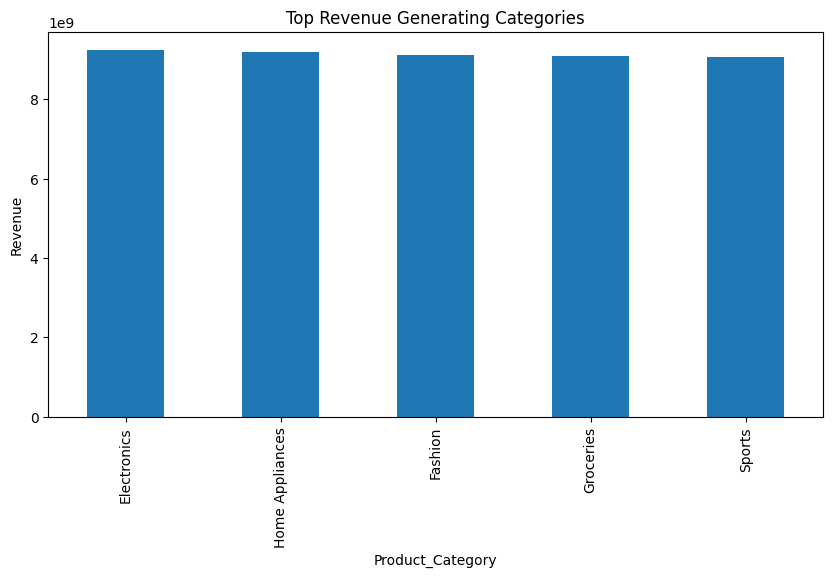

In [68]:
# Top Revenue Generating Categories

category_sales = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)

print("Top Revenue Categories")
print(category_sales.head())

category_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Revenue Generating Categories")
plt.ylabel("Revenue")
plt.show()

Top 10 Stores
Store_ID
STR_103   5,803,046,637.11
STR_102   5,758,117,039.56
STR_101   5,751,483,597.78
STR_104   5,749,821,347.88
STR_105   5,737,160,207.60
STR_107   5,672,850,014.33
STR_108   5,634,169,569.91
STR_106   5,601,443,053.40
Name: Total_Sales, dtype: float64


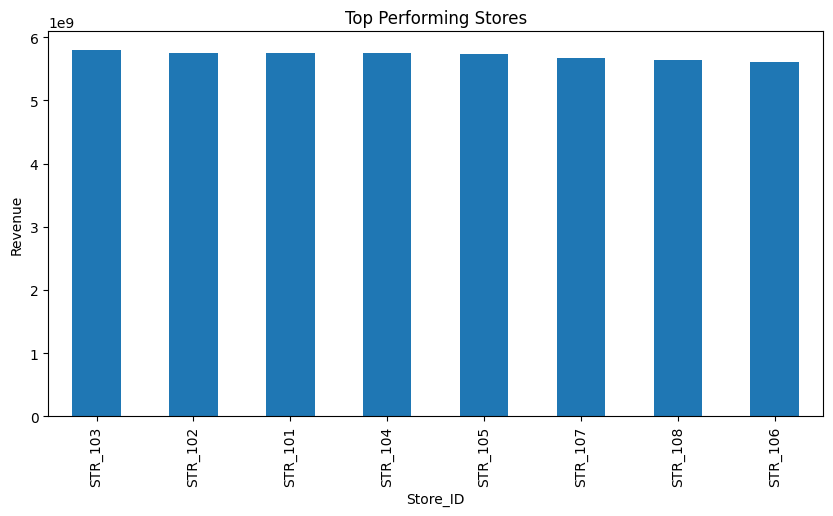

In [69]:
store_sales = df.groupby('Store_ID')['Total_Sales'].sum().sort_values(ascending=False)

print("Top 10 Stores")
print(store_sales.head(10))

store_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Performing Stores")
plt.ylabel("Revenue")
plt.show()

# Executive Summary

### Sales Analysis
- Multiple stores and product categories were analyzed.
- Seasonal trends and revenue patterns were identified.

### Forecasting
- Prophet and ARIMA models were used for future sales prediction.

### Store Segmentation
- K-Means clustering grouped stores into performance-based segments.

### Model Performance
- MAE: 6,576,983.15
- RMSE: 7,720,306.67

### Business Impact
The system enables data-driven inventory planning, revenue forecasting, and strategic decision-making.


# **Key Insights**
- Sales are not evenly distributed across products; a small subset of products contributes a significant portion of total revenue.

- Certain product categories consistently outperform others, indicating clear customer preferences.

- Sales show noticeable variation across time periods, suggesting seasonal or demand-based trends.

- Higher quantities sold do not always correspond to higher revenue, highlighting the impact of pricing.

- Some products exhibit stable sales patterns, while others show high volatility.

- Overall data analysis reveals opportunities for inventory optimization and targeted marketing strategies

# Conclusion

This Retail Analytics & AI-Powered Sales Forecasting System successfully analyzed retail sales data, identified key business trends, forecasted future revenue, and segmented stores using machine learning techniques.

The solution provides actionable insights that can support inventory optimization, marketing strategies, and business planning.